In [ ]:
#@title Importamos las librerías necesarias.
# Import the necessary libraries.
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import cv2
import random
import os
import math
import time
import statistics
from collections import defaultdict
from google.colab import drive
from google.colab.patches import cv2_imshow
from IPython.display import clear_output

!pip install ultralytics
!pip install gtts
#@title Librerías necesarias.
# Necessary Libraries.
import torch
import ultralytics
from ultralytics import YOLO
from ultralytics import RTDETR
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from torchvision.ops import nms
from gtts import gTTS
from IPython.display import Audio

#Librerías para la captura de video en tiempo real
from IPython.display import display, Javascript
from google.colab.output import eval_js
import base64
import io
import PIL.Image


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.0/90.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 3.5 MB/s eta 0:00:00
  Attempting uninstall: click
    Found existing installation: click 8.5.0
    Uninstalling click-8.5.0:
      Successfully uninstalled click-8.5.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
spacy 3.8.16 requires click<9.0.0,>=8.2.1, but you have click 8.1.8 which is incompatible.
wandb 0.28.1 requires click>=8.2.0, but you have click 8.1.8 which is incompatible.
huggingface-hub 1.29.0 requires click<9.0.0,>=8.4.2, but you have click 8.1.8 which is incompatible.
Creating n

In [ ]:
import os
import yaml
from tqdm import tqdm # Para mostrar el progreso

def remap_annotation_files(base_dataset_path, old_class_names, new_class_names):
    """
    Remaps class IDs in YOLO annotation files from an old class list to a new one,
    overwriting the original files.

    Args:
        base_dataset_path (str): The base path to your dataset (e.g., '/content/drive/MyDrive/Dataset - Frames').
                                 This path should contain 'train', 'val', 'test' subdirectories.
        old_class_names (list): A list of class names used in the existing annotation files.
        new_class_names (list): The target list of class names with correct order/IDs.
    """
    class_name_to_new_id = {name: i for i, name in enumerate(new_class_names)}

    print("Iniciando remapeo y SOBRESCRITURA de archivos de anotación...")
    print("¡ADVERTENCIA: Esta operación es IRREVERSIBLE! Asegúrate de tener una copia de seguridad.")

    for split in ['train', 'val', 'test']:
        labels_dir = os.path.join(base_dataset_path, split, 'labels')

        if not os.path.exists(labels_dir):
            print(f"Advertencia: La carpeta de etiquetas no existe para {split}: {labels_dir}. Saltando...")
            continue

        print(f"Procesando etiquetas para el split: {split}")
        annotation_files = [f for f in os.listdir(labels_dir) if f.endswith('.txt')]

        for filename in tqdm(annotation_files, desc=f"Remapeando y sobrescribiendo {split} labels"):
            filepath = os.path.join(labels_dir, filename)

            remapped_lines = []
            with open(filepath, 'r') as f_in:
                for line in f_in:
                    parts = line.strip().split()
                    if not parts: # Saltar líneas vacías
                        continue

                    old_class_id = int(parts[0])

                    if old_class_id >= len(old_class_names):
                        print(f"Advertencia: ID de clase fuera de rango ({old_class_id}) en {filename}, línea '{line.strip()}'. Saltando esta anotación.")
                        continue

                    old_class_name = old_class_names[old_class_id]

                    if old_class_name in class_name_to_new_id:
                        new_class_id = class_name_to_new_id[old_class_name]
                        remapped_line = f"{new_class_id} {' '.join(parts[1:])}"
                        remapped_lines.append(remapped_line)
                    else:
                        # Si un nombre de clase antiguo no está en la nueva lista, se omite.
                        print(f"Advertencia: Clase '{old_class_name}' (ID {old_class_id}) en {filename} no encontrada en la nueva lista de clases. Esta anotación será omitida.")

            # Sobrescribir el archivo original
            with open(filepath, 'w') as f_out:
                f_out.write('\n'.join(remapped_lines))
                if remapped_lines: # Añadir nueva línea al final solo si hay contenido
                    f_out.write('\n')

    print("\n¡Remapeo y sobrescritura de anotaciones completado!")
    print("Tus archivos de anotación originales han sido modificados directamente.")


### Uso de la función `remap_annotation_files` (¡Modifica archivos originales!)

Asegúrate de que la `dataset_base_path` sea correcta y que las listas `old_class_names` y `new_class_names` coincidan con tus expectativas. Esta operación **modificará permanentemente tus archivos de anotación**.

In [ ]:
# --- Define tus listas de clases ---
# Clases "mal cuadradas" (Roboflow):
old_class_names = [
    'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z',
    'a_tilde', 'apostrophe', 'capital', 'colon', 'e_tilde', 'exclamation_mark', 'hyphen', 'i_tilde', 'n_tilde', 'number_sign', 'o_tilde', 'period'
]

# Clases "buenas" (completas):
new_class_names = [
    'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z',
    'a_tilde', 'ampersand', 'apostrophe', 'asterisk', 'capital', 'close_parenthesis', 'closequotatioN', 'colon', 'comma', 'e_tilde', 'exclamation_mark', 'greaterthan', 'hyphen', 'i_tilde', 'lessthan', 'letter_sign', 'minus', 'n_tilde', 'number_sign', 'o_tilde', 'open_parenthesis', 'parentheses', 'period', 'question_mark', 'semicolon', 'slash', 'u_dieresis', 'u_tilde'
]

# Verifica que la longitud de las listas coincida con los 'nc' que mencionaste
print(f"Longitud de old_class_names: {len(old_class_names)}") # Debería ser 38
print(f"Longitud de new_class_names: {len(new_class_names)}") # Debería ser 54

# --- Define la ruta base de tu dataset ---
dataset_base_path = '/content/drive/MyDrive/Trabajo de Grado/Dataset - Simple_Frames'

# --- Ejecuta la función para remapear y sobrescribir los archivos de anotación ---
remap_annotation_files(
    base_dataset_path=dataset_base_path,
    old_class_names=old_class_names,
    new_class_names=new_class_names
)

print("\n¡Proceso completado! Tus archivos de anotación ahora deberían estar actualizados.")


Longitud de old_class_names: 38
Longitud de new_class_names: 54
Iniciando remapeo y SOBRESCRITURA de archivos de anotación...
¡ADVERTENCIA: Esta operación es IRREVERSIBLE! Asegúrate de tener una copia de seguridad.
Advertencia: La carpeta de etiquetas no existe para train: /content/drive/MyDrive/Trabajo de Grado/Dataset - Simple_Frames/train/labels. Saltando...
Advertencia: La carpeta de etiquetas no existe para val: /content/drive/MyDrive/Trabajo de Grado/Dataset - Simple_Frames/val/labels. Saltando...
Procesando etiquetas para el split: test


Remapeando y sobrescribiendo test labels: 100%|██████████| 107/107 [00:03<00:00, 33.10it/s]


¡Remapeo y sobrescritura de anotaciones completado!
Tus archivos de anotación originales han sido modificados directamente.

¡Proceso completado! Tus archivos de anotación ahora deberían estar actualizados.


In [ ]:
#@title Configurando el Drive.
# Setting up Drive.
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive')
print(os.getcwd())

Mounted at /content/drive
/content/drive/MyDrive


In [ ]:
#@title Definimos metodos importantes
#Metodo para obtener las annotaciones en un mismo formato.
#Method to obtain all annotations in the same format.
def parse_annotation(annotation_text):
    labels = []

    for line in annotation_text.strip().split("\n"):
          polygon = []
          values = line.split()

          for n in values:
            polygon.append(float(n))
          labels.append(polygon)

    return labels

#Metodo para dibujar poligonos/bounding boxes en la imagen.
#Method to draw the polygons/bounding boxes in the image.
def draw_polygons(image, labels, color=(86,5,145)):
    img = image.copy()

    h, w = img.shape[:2]
    for n in labels:
      if len(n) == 5:
        id_class = int(n[0])
        x1 = int((n[1] - n[3]/2) * w)
        y1 = int((n[2] - n[4]/2) * h)

        x2 = int((n[1] + n[3]/2) * w)
        y2 = int((n[2] + n[4]/2) * h)

        cv2.rectangle(img,(x1, y1),(x2, y2),color,2)

        cv2.putText(img, str(id_class), (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

      else:
        id_class = int(n[0])
        coords = np.array(n[1:], dtype=np.float32)

        coords[0::2] *= w  # x
        coords[1::2] *= h  # y

        pts = coords.reshape(-1, 2).astype(np.int32)

        cv2.polylines(img, [pts], isClosed=True, color=color, thickness=2)
        cv2.putText(img, str(id_class), (pts[0,0], pts[0,1]-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

    return img

def nms_Yolo(results, image, iou=0.3):
    # Obtenemos las cajas, los puntajes y las clases.
    # Get the boxes, scores and classes.
    boxes = results[0].boxes.xyxy
    scores = results[0].boxes.conf
    classes = results[0].boxes.cls

    # Aplicar NMS manualmente con IoU
    # Apply NMS manually with IoU
    keep = nms(boxes, scores, iou_threshold=iou)

    # Filtrar resultados
    # Filter the results
    filtered_boxes = boxes[keep]
    filtered_scores = scores[keep]
    filtered_classes = classes[keep]

    image = results[0].orig_img.copy()

    # Usa las predicciones filtradas con NMS
    # Use filtered predictions with NMS
    for i in range(len(keep)):
        cls = int(filtered_classes[i])
        conf = float(filtered_scores[i])
        x1, y1, x2, y2 = map(int, filtered_boxes[i])
        label = f"{results[0].names[cls]}"

        # Dibujar rectángulo
        # Draw the rectangle
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 255), 2)

        # Etiqueta con fondo
        # Label with background
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 1)
        cv2.rectangle(image, (x1, y1 - th - 4), (x1 + tw, y1), (0, 255, 255), -1)
        cv2.putText(image, label, (x1, y1 - 4), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 1)

    text = spatial_organization(results, keep, filtered_boxes, filtered_classes)

    return image, text

def spatial_organization(results, keep, filtered_boxes, filtered_classes):
    # Declaramos un diccionario para caracteres especiales
    special_characters = {
        'a_tilde': 'á', 'ampersand': '&', 'apostrophe': "'", 'asterisk': '*', 'close_parenthesis': ')', 'closequotation': '"', 'colon': ':', 'comma': ',', 'e_tilde': 'é', 'exclamation_mark': '!', 'greaterthan': '>', 'hyphen': '-', 'i_tilde': 'í', 'lessthan': '<', 'minus': '-', 'n_tilde': 'ñ', 'o_tilde': 'ó', 'open_parenthesis': '(', 'parentheses': '()', 'period': '.', 'question_mark': '?', 'semicolon': ';', 'slash': '/', 'u_dieresis': 'ü', 'u_tilde': 'ú'
    }
    numbers = {
        'j': '0', 'a': '1', 'b': '2', 'c': '3', 'd': '4', 'e': '5', 'f': '6', 'g': '7', 'h': '8', 'i': '9'
    }
    #Instanciamos una lista para guardar la altura de las bounding boxes
    y_difference = []
    # Agrupar por líneas (por y1)
    line_groups = defaultdict(list)
    #Revisamos que hayan bounding boxes que organizar
    lenght = len(filtered_boxes)
    if lenght == 0:
      return []
    else:
      for n in range(len(keep)):
        y_difference.append(np.abs(filtered_boxes[n][1].item()-filtered_boxes[n][3].item()))

    #Sacamos un promedio de las alturas de todas las letras
    y_threshold = statistics.mean(y_difference)
    y_threshold = y_threshold * 0.9 # tolerancia vertical en píxeles

    #Ordenamos las cajas respecto a sus posiciones en X (De izquierda a derecha)
    ordered_boxes = sorted(zip(filtered_boxes,filtered_classes), key= lambda x: x[0][0])
    filtered_boxes = [x for x,y in ordered_boxes]
    filtered_classes = [y for x,y in ordered_boxes]

    # Agrupar letras por líneas
    for i in range(len(keep)):
        #Extraer los datos de todas las detecciones, clase como string, bounding box y la posición en Y centrada
        cls = int(filtered_classes[i])
        letra = results[0].names[cls].lower()
        x1, y1, x2, y2 = filtered_boxes[i].tolist()
        y_center = (y1 + y2) / 2

        # Asignar a una línea existente o crear una nueva
        added = False

        #Iteramos por todas las bounding boxes mirando cuales están dentro de la tolerancia vertical de la primera, así separaos las lineas
        for key in line_groups:
            if abs(key - y_center) < y_threshold:
                line_groups[key].append((x1, letra))
                added = True
                break
        if not added:
            line_groups[y_center].append((x1, letra))

    # Ordenamos las líneas verticalmente (de arriba hacia abajo)
    sorted_lines = sorted(line_groups.items(), key=lambda x: x[0])

    # Instanciamos lista para el texto final
    texto_final = []
    for _, letras in sorted_lines:
        letras.sort(key=lambda x: x[0])  # ordenar letras por x

        #Aplicar transforamciones a caracteres especiales
        for n in range(len(letras)):
            if letras[n][1] in special_characters:
                letras[n] = (letras[n][0], special_characters[letras[n][1]])
            if letras[n][1] == 'capital':
                letras[n] = (letras[n][0], '')
                if n+1 < len(letras):
                  letras[n+1] = (letras[n+1][0], letras[n+1][1].upper())
            if letras[n][1] == 'number_sign':
                letras[n] = (letras[n][0], '')
                if n+1 < len(letras):
                  if letras[n+1][1] in numbers:
                    letras[n+1] = (letras[n+1][0], numbers[letras[n+1][1]])
            if letras[n][1] == 'letter_sign':
                letras[n] = (letras[n][0], '')

        # Calcular distancia promedio entre letras
        # Se extraen las coordenadas en x
        x_coords = [x for x, _ in letras]
        # Se calculan las distancias
        dists = [x_coords[i+1] - x_coords[i] for i in range(len(x_coords)-1)]
        if len(dists) > 0:
            avg_dist = sum(dists) / len(dists)
        else:
            avg_dist = 0
        space_threshold = avg_dist * 1.2  # Tolerancia horizontal + 20% de error

        # Construir línea con espacios
        linea = letras[0][1]
        for i in range(1, len(letras)):
            # Se calcula la distancia
            gap = letras[i][0] - letras[i-1][0]
            if gap > space_threshold: #Si la distancia es mayor al umbral, se pone un espacio
                linea += ' '  # espacio entre palabras
            linea += letras[i][1]

        texto_final.append(linea)

    return texto_final

def play_text(input_text, lan="en", output_filename="temp_audio.mp3", autoplay=True): # Modified to accept filename and autoplay
    if not input_text:
        return None
    else:
        tts = gTTS(input_text, lang=lan)
        tts.save(output_filename)
    if autoplay:
        return Audio(output_filename, autoplay=True)
    return output_filename # Return the filename if not autoplaying

In [ ]:
def video_translation(video_path):
  #Load the video
  cap = cv2.VideoCapture(video_path)

  # Initialize video capture and get properties
  fps = int(cap.get(cv2.CAP_PROP_FPS))
  width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
  height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

  # Define the codec and create VideoWriter object
  fourcc = cv2.VideoWriter_fourcc(*'XVID') # Changed from 'mp4v' to 'XVID'
  out = cv2.VideoWriter('VideoResults/output.mp4', fourcc, fps, (width, height))

  #Save the Inference speeds
  inference_times = []

  while cap.isOpened():
      ret, frame = cap.read()
      if not ret:
        break;
      # Perform object detection
      results = model.predict(frame)
      inference_speed = results[0].speed
      inference_times.append(inference_speed['inference'])

      # Apply NMS and Organize the letters
      frame, translated_text = nms_Yolo(results, frame)
      print(translated_text)

      out.write(frame) # Write the frame to the saved file
  cap.release()

  return inference_times

In [ ]:
text_sample = ["Cambió", "todo en mí", "luego de que llegaras"]
print(" ".join(text_sample))
play_text("".join(text_sample), lan="es")

Cambió todo en mí luego de que llegaras


In [ ]:
model = YOLO('Trabajo de Grado/Dataset - Yolo/runs/detect/trainv8/weights/best.pt')

In [ ]:
inference_yolo = video_translation("BrailleDatasetVideo/video_20260820_140407.mp4")


0: 640x384 (no detections), 7.1ms
Speed: 2.2ms preprocess, 7.1ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 384)
[]

0: 640x384 (no detections), 9.6ms
Speed: 2.5ms preprocess, 9.6ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 384)
[]

0: 640x384 (no detections), 7.8ms
Speed: 1.8ms preprocess, 7.8ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 384)
[]

0: 640x384 (no detections), 7.8ms
Speed: 1.8ms preprocess, 7.8ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 384)
[]

0: 640x384 (no detections), 7.7ms
Speed: 1.8ms preprocess, 7.7ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 384)
[]

0: 640x384 (no detections), 7.8ms
Speed: 1.9ms preprocess, 7.8ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 384)
[]

0: 640x384 (no detections), 7.7ms
Speed: 1.8ms preprocess, 7.7ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 384)
[]

0: 640x384 (no detections), 10.0ms
Speed: 2.5ms preprocess, 1

In [ ]:
model = RTDETR("Trabajo de Grado/runs/detect/train/weights/best.pt")

In [ ]:
inference_trans = video_translation("BrailleDatasetVideo/video_20260820_140718.mp4")


0: 640x640 20 As, 1 C, 2 Ds, 5 Es, 1 F, 4 Gs, 1 H, 15 Is, 1 L, 2 Ms, 11 Ns, 9 Os, 3 Rs, 6 Ts, 1 X, 2 Ys, 1 capital, 45.5ms
Speed: 2.9ms preprocess, 45.5ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)
['g', 'D', 'aanaa innat ranaan n ii na a', 'ta ianrni oi giin aa', 'taeo h i', 'yoltfao x']

0: 640x640 12 As, 2 Cs, 1 E, 2 Gs, 7 Is, 1 K, 2 Ms, 5 Ns, 4 Os, 3 Rs, 2 Ss, 4 Ts, 4 Us, 2 Vs, 2 Ws, 1 a_tilde, 1 capital, 1 hyphen, 40.9ms
Speed: 2.7ms preprocess, 40.9ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)
['aa', 'nn ag', 'aaiaainc i ww', 'ruu I', '-', 'tuas toeu a', 'grvn']

0: 640x640 7 As, 3 Cs, 2 Ds, 2 Es, 1 F, 3 Gs, 7 Is, 2 Ls, 3 Ms, 5 Ns, 4 Os, 1 R, 2 Ss, 4 Ts, 1 U, 2 Vs, 1 Y, 1 a_tilde, 2 hyphens, 40.9ms
Speed: 2.7ms preprocess, 40.9ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)
['na', 'acia noi o t', 'g', 'iai - u', 'tistema', 'gryfico']

0: 640x640 4 As, 1 B, 2 Cs, 2 Es, 1 F, 1 G, 4 Is, 2 Ls, 2 Ms, 3 Ns, 4 Os, 2 Ss, 4 

In [ ]:
print("--------------------------------------------------------------------------")
print("Tiempos de inferencia")
print("--------------------------------------------------------------------------")
print(f"YOLO: {np.mean(inference_yolo)} ms")
print(f"RTDETR: {np.mean(inference_trans)} ms")

--------------------------------------------------------------------------
Tiempos de inferencia
--------------------------------------------------------------------------
YOLO: 8.162075394121155 ms
RTDETR: 41.762505564720946 ms


In [ ]:
from difflib import SequenceMatcher

def video_translation(video_path, audio_output_dir="VideoResults/audio_segments"):
  os.makedirs('VideoResults', exist_ok=True)
  os.makedirs(audio_output_dir, exist_ok=True) # Ensure audio segments directory exists

  cap = cv2.VideoCapture(video_path)
  fps = int(cap.get(cv2.CAP_PROP_FPS))
  width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
  height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

  fourcc = cv2.VideoWriter_fourcc(*'mp4v')
  output_silent_video_path = 'VideoResults/output_silent.mp4'
  out = cv2.VideoWriter(output_silent_video_path, fourcc, fps, (width, height))

  # List to store (text, start_frame_index, end_frame_index) segments
  text_segments_for_audio = []
  current_text_content = ""
  current_text_start_frame = 0

  frame_idx = 0
  while cap.isOpened():
      ret, frame = cap.read()
      if not ret:
          break

      if frame_idx % 5 == 0: # Process every 10th frame
          # Perform object detection
          results = model.predict(frame)
          frame, translated_text_list = nms_Yolo(results, frame)

          # Combine list of texts into a single string for this frame
          text_this_frame = " ".join(translated_text_list)
          print("Detección Anterior: ", current_text_content)
          print("Detección este Frame: ", text_this_frame)

          text_match = SequenceMatcher(None, current_text_content, text_this_frame).ratio()
          print("Porcentaje de coincidencia: ", text_match)

          # Check for change in text content
          if text_this_frame != current_text_content:
              if text_this_frame: # If there was previous text, record its segment
                  if text_match < 0.75:
                      text_segments_for_audio.append({
                          'text': text_this_frame,
                          'start_frame': current_text_start_frame,
                      })
                      print("Texto añadido:", text_this_frame)

              # Start a new segment
              current_text_content = text_this_frame
              current_text_start_frame = frame_idx

      out.write(frame)

      frame_idx += 1

  # Record the last segment if the video ends with text
  if current_text_content:
      text_segments_for_audio.append({
          'text': current_text_content,
          'start_frame': current_text_start_frame,
      })

  cap.release()
  out.release()

  # Get total video duration in seconds
  video_duration_seconds = (frame_idx) / fps

  return output_silent_video_path, text_segments_for_audio, fps, video_duration_seconds

In [ ]:
silent_video_path, text_segments_for_audio, fps, video_duration_seconds = video_translation("BrailleDatasetVideo/video_20260820_140407.mp4")


0: 640x384 (no detections), 608.2ms
Speed: 22.1ms preprocess, 608.2ms inference, 13.5ms postprocess per image at shape (1, 3, 640, 384)
Detección Anterior:  
Detección este Frame:  
Porcentaje de coincidencia:  1.0

0: 640x384 (no detections), 358.3ms
Speed: 5.9ms preprocess, 358.3ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 384)
Detección Anterior:  
Detección este Frame:  
Porcentaje de coincidencia:  1.0

0: 640x384 (no detections), 328.5ms
Speed: 8.3ms preprocess, 328.5ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 384)
Detección Anterior:  
Detección este Frame:  
Porcentaje de coincidencia:  1.0

0: 640x384 1 E, 1 G, 1 N, 1 R, 348.4ms
Speed: 5.8ms preprocess, 348.4ms inference, 26.0ms postprocess per image at shape (1, 3, 640, 384)
Detección Anterior:  
Detección este Frame:  engr
Porcentaje de coincidencia:  0.0
Texto añadido: engr

0: 640x384 2 Es, 1 G, 1 N, 1 O, 1 R, 1 S, 493.6ms
Speed: 6.0ms preprocess, 493.6ms inference, 1.4ms postprocess p

In [ ]:
print(text_segments_for_audio)

[{'text': 'engr', 'start_frame': 0}, {'text': 'angreso a', 'start_frame': 45}, {'text': 'engreso', 'start_frame': 65}]


In [ ]:
import moviepy.editor as mpy_editor

# Define audio output directory
audio_output_dir = "VideoResults/audio_segments"
os.makedirs(audio_output_dir, exist_ok=True)

all_audio_clips = []
total_duration = 0

for i, segment in enumerate(text_segments_for_audio):
    segment_start_time = segment['start_frame'] / fps

    print("----------------------------------------------------------------------------------------------------")
    if segment_start_time < total_duration:
        print("---------------------------")
        print(f"Segmento {segment['text']} no fue procesado, ya se está reproduciendo otro segmento en este momento")
        #break;
        #El break rompe el codigo saltandose segmentos

    else:
        audio_filename = os.path.join(audio_output_dir, f"segment_audio_{i:04d}.mp3")
        play_text(segment['text'], lan="es", output_filename=audio_filename, autoplay=False) # Idioma cambiado a 'es'
        py_audio = mpy_editor.AudioFileClip(audio_filename)
        #py_audio = py_audio.set_duration(segment_duration)
        total_duration += py_audio.duration
        all_audio_clips.append(py_audio)
        print("---------------------------")
        print(f"Segmento {segment['text']} procesado")
        print("Duración del segmento:", py_audio.duration)


    print("----------------------------------")
    print("Duración Total", total_duration)
    print("----------------------------------------------------------------------------------------------------")

if all_audio_clips:
    combined_audio = mpy_editor.concatenate_audioclips(all_audio_clips)

# Carga el video silencioso
video_clip = mpy_editor.VideoFileClip(silent_video_path)

# Establece el audio en el clip de video
final_clip = video_clip.set_audio(combined_audio)

# Define el directorio de salida para el video final
output_final_video_dir = "VideoResults/VideoNAudio"
os.makedirs(output_final_video_dir, exist_ok=True)
final_video_path = os.path.join(output_final_video_dir, "final_video_with_audio.mp4")

# Escribe el video final
final_clip.write_videofile(final_video_path, codec="libx264", audio_codec="aac")

print(f"Video final con audio guardado en: {final_video_path}")

----------------------------------------------------------------------------------------------------
---------------------------
Segmento engr procesado
Duración del segmento: 0.74
----------------------------------
Duración Total 0.74
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
---------------------------
Segmento angreso a procesado
Duración del segmento: 1.3
----------------------------------
Duración Total 2.04
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
---------------------------
Segmento engreso procesado
Duración del segmento: 1.08
----------------------------------
Duración Total 3.12
-----------------------------------------------------------------------------------

MoviePy - Done.
Moviepy - Writing video VideoResults/VideoNAudio/final_video_with_audio.mp4



t:  97%|█████████▋| 65/67 [00:03<00:00, 20.93it/s, now=None]WARNING:py.warnings:/usr/local/lib/python3.13/dist-packages/moviepy/video/io/ffmpeg_reader.py:123: UserWarning: Warning: in file VideoResults/output_silent.mp4, 6220800 bytes wanted but 0 bytes read,at frame 66/67, at time 2.28/2.28 sec. Using the last valid frame instead.
  warnings.warn("Warning: in file %s, "%(self.filename)+



Moviepy - Done !
Moviepy - video ready VideoResults/VideoNAudio/final_video_with_audio.mp4
Video final con audio guardado en: VideoResults/VideoNAudio/final_video_with_audio.mp4


In [ ]:
from IPython.display import HTML
from base64 import b64encode

# Specify the path to your video file
video_path = 'BrailleDatasetVideo/video_20260716_155830.mp4'

# Encode video to base64
mp4 = open(video_path, 'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

# Render the HTML player
HTML(f"""
<video width="640" height="480" controls>
      <source src="{data_url}" type="video/mp4">
</video>
""")

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
from IPython.display import HTML
from base64 import b64encode

# Specify the path to your video file
video_path = 'VideoResults/VideoNAudio/final_video_with_audio.mp4'

# Encode video to base64
mp4 = open(video_path, 'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

# Render the HTML player
HTML(f"""
<video width="640" height="480" controls>
      <source src="{data_url}" type="video/mp4">
</video>
""")

In [ ]:
#@title Extraccion de fotogramas a los videos

import cv2
import os
from google.colab import drive

VIDEO_FOLDER = '/content/drive/MyDrive/BrailleDatasetVideo'

# Carpeta para guardar fotogramas de los videos
OUTPUT_FOLDER = '/content/drive/MyDrive/Fotogramas/'

# Crear la carpeta si no existe
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# Prueba con uno de los videos
video_name = 'video_20260905_144222.mp4'
video_path = os.path.join(VIDEO_FOLDER, video_name)

# Verifica que el video existe
if not os.path.exists(video_path):
    print(f" ERROR: No se encontro el video: {video_path}")
    print(" Contenido de la carpeta de videos:")
    for f in os.listdir(VIDEO_FOLDER):
        print(f"   - {f}")
else:
    print(f" Video encontrado: {video_name}")

    # Configurar extracción
    STEP = 5
    base_name = os.path.splitext(video_name)[0]
    video_output_folder = os.path.join(OUTPUT_FOLDER, base_name)
    os.makedirs(video_output_folder, exist_ok=True)

    cap = cv2.VideoCapture(video_path)
    frame_count = 0
    saved_count = 0

    print(f" Procesando el video: {video_name} ...")
    print(f"   STEP = {STEP} (guarda 1 de cada {STEP} fotogramas)")

    # Extraer fotogramas
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_count % STEP == 0:
            frame_name = f'{base_name}_frame_{saved_count:04d}.jpg'
            frame_path = os.path.join(video_output_folder, frame_name)
            cv2.imwrite(frame_path, frame)
            saved_count += 1

        frame_count += 1

        # Mostrar progreso cada 50 fotogramas
        if frame_count % 50 == 0:
            print(f"   Procesados {frame_count} fotogramas...")

    cap.release()

    # 8. Mostrar resumen
    print(f"\n Completado")
    print(f"   Total fotogramas en el video: {frame_count}")
    print(f"   Fotogramas guardados: {saved_count}")
    print(f" Carpeta: {video_output_folder}")

 Video encontrado: video_20260905_144222.mp4
 Procesando el video: video_20260905_144222.mp4 ...
   STEP = 5 (guarda 1 de cada 5 fotogramas)

 Completado
   Total fotogramas en el video: 37
   Fotogramas guardados: 8
 Carpeta: /content/drive/MyDrive/Fotogramas/video_20260905_144222


In [ ]:
#@title Extraccion de fotogramas a TODOS los videos
VIDEO_FOLDER = '/content/drive/MyDrive/BrailleDatasetVideo'

# Carpeta para guardar fotogramas de los videos
OUTPUT_FOLDER = '/content/drive/MyDrive/Fotogramas/'

# Crear la carpeta si no existe
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

videos = os.listdir(VIDEO_FOLDER)
videos_path = [os.path.join(VIDEO_FOLDER, video) for video in videos]

for video_path in videos_path:

    video_name = os.path.basename(video_path)
    # Verifica que el video existe
    if not os.path.exists(video_path):
        print(f" ERROR: No se encontro el video: {video_path}")
        print(" Contenido de la carpeta de videos:")
        for f in os.listdir(VIDEO_FOLDER):
            print(f"   - {f}")
    else:
        print(f" Video encontrado: {video_name}")

        # Configurar extracción
        STEP = 5
        base_name = os.path.splitext(video_name)[0]
        video_output_folder = os.path.join(OUTPUT_FOLDER, base_name)
        os.makedirs(video_output_folder, exist_ok=True)

        cap = cv2.VideoCapture(video_path)
        frame_count = 0
        saved_count = 0

        print(f" Procesando el video: {video_name} ...")
        print(f"   STEP = {STEP} (guarda 1 de cada {STEP} fotogramas)")

        # Extraer fotogramas
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            if frame_count % STEP == 0:
                frame_name = f'{base_name}_frame_{saved_count:04d}.jpg'
                frame_path = os.path.join(video_output_folder, frame_name)
                cv2.imwrite(frame_path, frame)
                saved_count += 1

            frame_count += 1

            # Mostrar progreso cada 50 fotogramas
            if frame_count % 50 == 0:
                print(f"   Procesados {frame_count} fotogramas...")

        cap.release()

        # 8. Mostrar resumen
        print(f"\n Completado")
        print(f"   Total fotogramas en el video: {frame_count}")
        print(f"   Fotogramas guardados: {saved_count}")
        print(f" Carpeta: {video_output_folder}")

 Video encontrado: video_20260530_175700.mp4
 Procesando el video: video_20260530_175700.mp4 ...
   STEP = 5 (guarda 1 de cada 5 fotogramas)
   Procesados 50 fotogramas...
   Procesados 100 fotogramas...

 Completado
   Total fotogramas en el video: 121
   Fotogramas guardados: 25
 Carpeta: /content/drive/MyDrive/Fotogramas/video_20260530_175700
 Video encontrado: VID-20260602-WA0001.mp4
 Procesando el video: VID-20260602-WA0001.mp4 ...
   STEP = 5 (guarda 1 de cada 5 fotogramas)
   Procesados 50 fotogramas...
   Procesados 100 fotogramas...
   Procesados 150 fotogramas...
   Procesados 200 fotogramas...
   Procesados 250 fotogramas...
   Procesados 300 fotogramas...

 Completado
   Total fotogramas en el video: 339
   Fotogramas guardados: 68
 Carpeta: /content/drive/MyDrive/Fotogramas/VID-20260602-WA0001
 Video encontrado: video_20260209_090715.mp4
 Procesando el video: video_20260209_090715.mp4 ...
   STEP = 5 (guarda 1 de cada 5 fotogramas)
   Procesados 50 fotogramas...
   Procesa

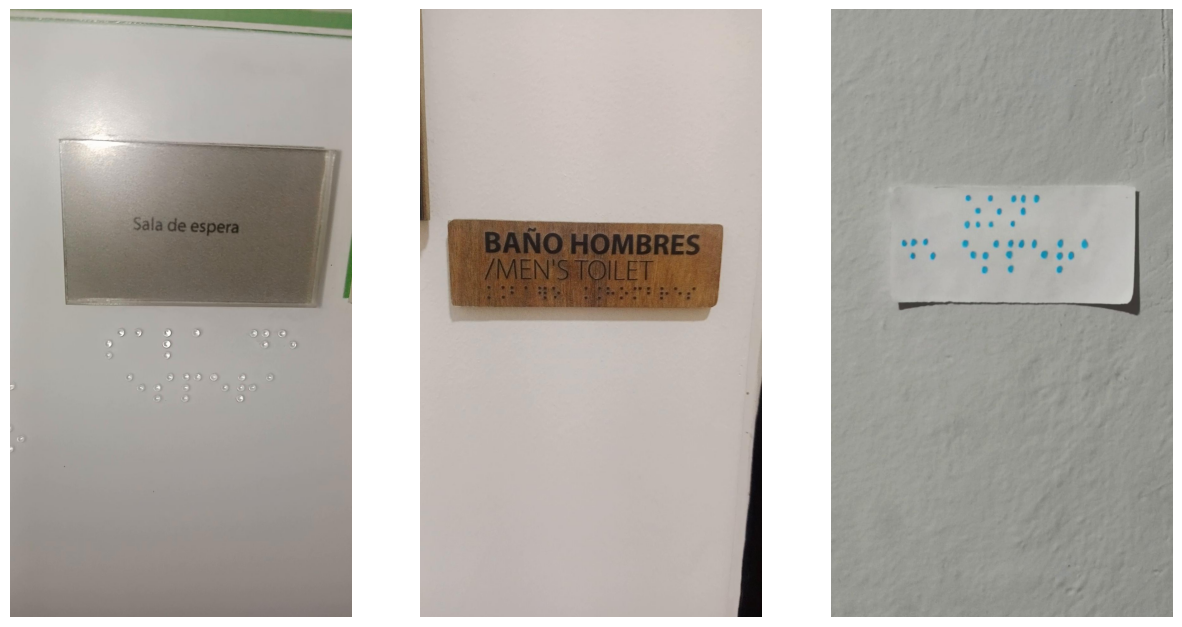

In [ ]:
#@title Sacando muestras de los frames sin etiquetar

#@title Collage de 6 muestras
test_path = "Trabajo de Grado/Dataset - Frames/test/"
images_jpg = sorted(os.listdir(f'{test_path}/images'))
indxs = random.choices(images_jpg,k=3)

image_sample = []

for indx in indxs:
  image_sample.append(cv2.imread(os.path.join(test_path, "images", indx), cv2.IMREAD_COLOR))

plt.figure(figsize=(15,15))
plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(image_sample[0], cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(image_sample[1], cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(image_sample[2], cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.show()

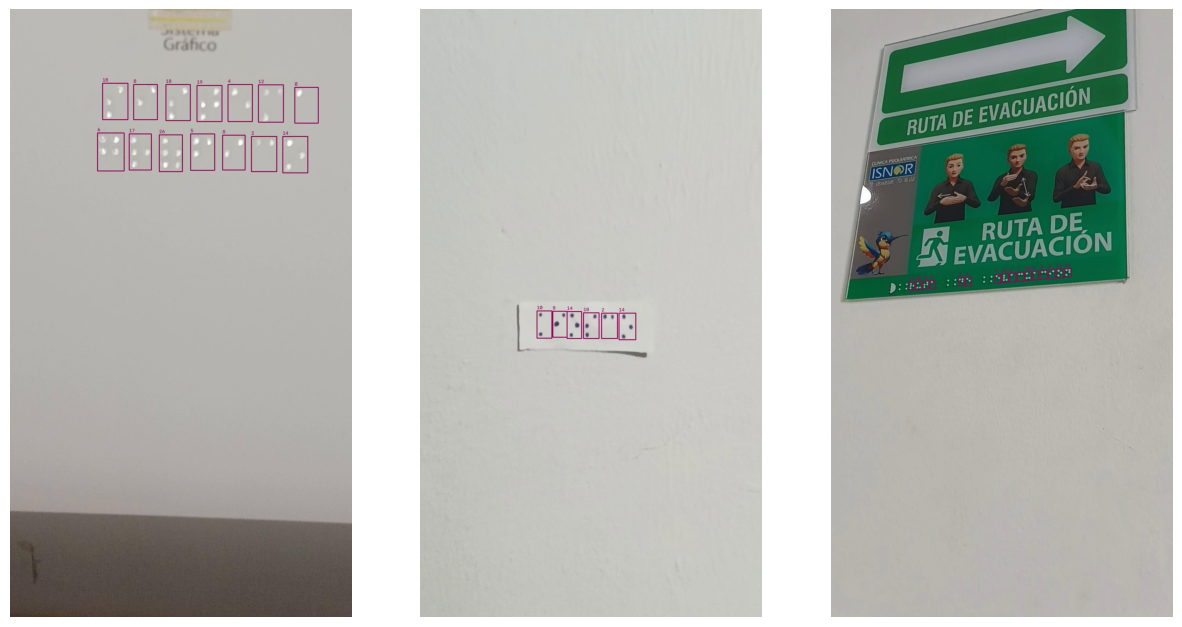

In [ ]:
#@title Sacando muestras de los frames etiquetados
#@title Collage de 6 muestras etiquetadas
test_path = "Trabajo de Grado/Dataset - Frames/test/"
images_jpg = sorted(os.listdir(f'{test_path}/images'))
labels_txt = sorted(os.listdir(f'{test_path}/labels'))
indxs = random.choices(range(len(images_jpg)),k=3)

image_sample = []
label_sample = []

for indx in indxs:
  image_sample.append(cv2.imread(os.path.join(test_path, "images", images_jpg[indx]), cv2.IMREAD_COLOR))
  label = open(os.path.join(test_path, "labels", labels_txt[indx]), "r").read()
  label = parse_annotation(label)
  label_sample.append(label)

plt.figure(figsize=(15,15))
plt.subplot(1,3,1)
img_boxes = draw_polygons(image_sample[0], label_sample[0])
plt.imshow(cv2.cvtColor(img_boxes, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,3,2)
img_boxes = draw_polygons(image_sample[1], label_sample[1])
plt.imshow(cv2.cvtColor(img_boxes, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,3,3)
img_boxes = draw_polygons(image_sample[2], label_sample[2])
plt.imshow(cv2.cvtColor(img_boxes, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.show()

### Validando con frames clave del dataset de videos

In [ ]:
#@title Validando con frames clave del dataset de videos
model = YOLO('Trabajo de Grado/Dataset - Yolo/runs/detect/trainv8/weights/best.pt')
metrics_Yolo = model.val(data="Trabajo de Grado/Dataset - Frames/data.yaml", split='test')

Ultralytics 8.4.161 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
Model summary (fused): 73 layers, 11,146,482 parameters, 0 gradients, 28.5 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 43.2±94.9 ms, read: 20.1±27.2 MB/s, size: 83.5 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /content/drive/MyDrive/Trabajo de Grado/Dataset - Frames/test/labels... 125 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 125/125 4.3it/s 29.2s
val: New cache created: /content/drive/MyDrive/Trabajo de Grado/Dataset - Frames/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 6.9s/it 55.5s
                   all        125       2458       0.52      0.459      0.431      0.259
                     A         99        290      0.528      0.583      0.529      0.233
                     B         28      

In [ ]:
#@title Validando con frames clave del dataset de videos
model_trans = RTDETR('Trabajo de Grado/runs/detect/train_trans/weights/best.pt')
metrics_trans = model_trans.val(data="Trabajo de Grado/Dataset - Frames/data.yaml", split='test')

Ultralytics 8.4.161 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
rt-detr-l summary (fused): 315 layers, 32,094,710 parameters, 0 gradients, 105.6 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.3 ms, read: 67.3±16.2 MB/s, size: 91.3 KB)
val: Scanning /content/drive/MyDrive/Trabajo de Grado/Dataset - Frames/test/labels.cache... 125 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 125/125 23.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 30.6s/it 4:05
                   all        125       2458      0.672       0.54      0.583      0.355
                     A         99        290      0.825      0.618      0.679      0.335
                     B         28         36      0.689      0.444      0.544      0.207
                     C         66        112      0.851      0.732      0.759      0.446
                     D         68        120      0.842      0.433      0.568      0.318
               

In [ ]:
print("------------------------------------------Yolov8s Metrics------------------------------------------")
print("mAP50:", metrics_Yolo.box.map50)         # mAP@0.5
print("mAP50-95:", metrics_Yolo.box.map)        # mAP@[.5:.95]
print("F1 Score", metrics_Yolo.box.f1)
print("Avg F1 Score", statistics.mean(metrics_Yolo.box.f1))
print("Precision:", metrics_Yolo.box.p)      # Precisión
print("Avg Precision", statistics.mean(metrics_Yolo.box.p)) #Precisión Promedio
print("Recall:", metrics_Yolo.box.r)          # Recall
print("Avg Recall", statistics.mean(metrics_Yolo.box.r))

------------------------------------------Yolov8s Metrics------------------------------------------
mAP50: 0.4307221316886212
mAP50-95: 0.25874117433799304
F1 Score [    0.55405     0.43354     0.64611     0.51361      0.5531     0.18737     0.58212     0.24194     0.45969     0.25885     0.22682     0.52319     0.65379     0.59721     0.62969     0.60519     0.29842     0.61099     0.71278     0.52058     0.54325     0.37676     0.23716     0.73433      0.3094     0.57681
     0.32061           0     0.23068      0.2504     0.27293           0     0.19193           0           0     0.57837     0.44419     0.71975]
Avg F1 Score 0.41041120943351167
Precision: [    0.52803     0.37425     0.62418     0.53673     0.50913     0.13802     0.51661     0.15346     0.35789     0.55257     0.13736     0.49347      0.6949     0.60323     0.64164      0.7416     0.25811     0.58191     0.85567     0.51204     0.54435     0.36921     0.13453     0.70245     0.27292     0.73733
     0.80764       

In [ ]:
print("------------------------------------------RT-DETR Metrics------------------------------------------")
print("mAP50:", metrics_trans.box.map50)         # mAP@0.5
print("mAP50-95:", metrics_trans.box.map)        # mAP@[.5:.95]
print("F1 Score", metrics_trans.box.f1)
print("Avg F1 Score", statistics.mean(metrics_trans.box.f1))
print("Precision:", metrics_trans.box.p)      # Precisión
print("Avg Precision", statistics.mean(metrics_trans.box.p)) #Precisión Promedio
print("Recall:", metrics_trans.box.r)          # Recall
print("Avg Recall", statistics.mean(metrics_trans.box.r))

------------------------------------------RT-DETR Metrics------------------------------------------
mAP50: 0.582508825989151
mAP50-95: 0.3548695145477927
F1 Score [      0.707     0.54041     0.78696     0.57224     0.78046     0.57795     0.72718     0.59365     0.72852     0.60906     0.42201     0.62339     0.76181     0.72788     0.70644     0.69163     0.54399     0.74005     0.80711     0.70201     0.71779     0.61072     0.23391     0.87199      0.3111      0.2356
     0.23203     0.27858     0.57406     0.53211     0.34376           0     0.52272     0.23483           0     0.71477     0.42361     0.65865]
Avg F1 Score 0.5485778156916266
Precision: [    0.82516     0.68922     0.85066      0.8422     0.89172     0.53749     0.68949     0.50788     0.76306     0.93896     0.33058     0.64052     0.79844     0.73412     0.75514     0.76642     0.49754     0.83525     0.90355     0.82348     0.86291     0.70539     0.15266     0.89945     0.19886      0.4639
     0.89305     0.458

/content/drive/MyDrive

image 1/1 /content/drive/MyDrive/Trabajo de Grado/Dataset - Frames/test/images/video_20260820_140530_frame_0007_jpg.rf.065aefccd92b6aa4b6f6b6f4cac23e2e.jpg: 640x384 1 C, 1 D, 1 E, 2 Is, 1 O, 2 Rs, 1 T, 368.5ms
Speed: 5.3ms preprocess, 368.5ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 384)
Clase: O, Confianza: 0.94, Coordenadas: [730.6712646484375, 661.172607421875, 824.7647705078125, 804.0451049804688]
Clase: R, Confianza: 0.93, Coordenadas: [351.03790283203125, 656.1090087890625, 432.9605712890625, 785.8673095703125]
Clase: D, Confianza: 0.84, Coordenadas: [163.05450439453125, 649.1395263671875, 249.59033203125, 775.193359375]
Clase: R, Confianza: 0.83, Coordenadas: [830.3827514648438, 659.3860473632812, 928.1716918945312, 810.3787231445312]
Clase: I, Confianza: 0.82, Coordenadas: [446.3863220214844, 658.4417724609375, 527.7833862304688, 787.2103271484375]
Clase: T, Confianza: 0.79, Coordenadas: [631.9293823242188, 658.1123657226562, 724.83563

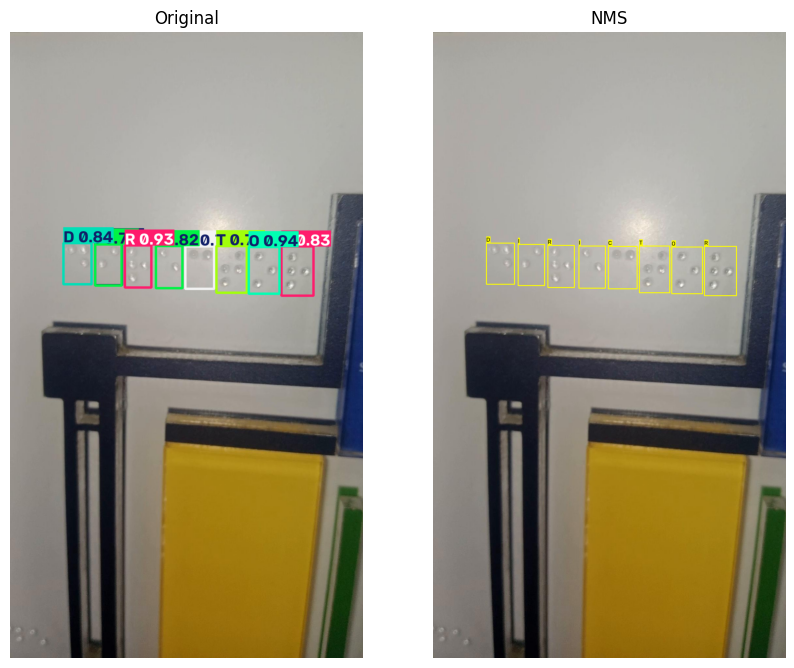

---------------------
dirictor
---------------------
['dirictor']
---------------------


In [ ]:
# Carga tu modelo entrenado.
# Load the trained model.
yolo_trained = YOLO('Trabajo de Grado/Dataset - Yolo/runs/detect/trainv8/weights/best.pt')

# Haz una predicción sobre una imagen.
# Make a prediction on an image.
print(os.getcwd())

Frame_FOLDER = '/content/drive/MyDrive/Trabajo de Grado/Dataset - Frames/test/images'
frames = os.listdir(Frame_FOLDER)
res = random.choice(frames)

results = yolo_trained.predict(
    source= os.path.join(Frame_FOLDER, res),
    save=False,
    conf=0.25)

# Mostrar resultados en texto.
# Show results on text.
for box in results[0].boxes:
    cls = int(box.cls[0])
    conf = float(box.conf[0])
    coords = box.xyxy[0].tolist()
    print(f"Clase: {results[0].names[cls]}, Confianza: {conf:.2f}, Coordenadas: {coords}")

# Mostrar la imagen
nms_results, text_results = nms_Yolo(results, results[0].orig_img, iou=0.3)
nms_results = cv2.cvtColor(nms_results, cv2.COLOR_BGR2RGB)
og_results = cv2.cvtColor(results[0].plot(), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(og_results)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("NMS")
plt.imshow(nms_results)
plt.axis('off')

plt.show()

print("---------------------")
for line in text_results:
    print(line)
print("---------------------")
print(text_results)
print("---------------------")



### Validando con frames complejos

In [ ]:
model = YOLO('Trabajo de Grado/Dataset - Yolo/runs/detect/trainv8/weights/best.pt')
metrics_Yolo = model.val(data="Trabajo de Grado/Dataset - Complex_Frames/data.yaml", split='test')

Ultralytics 8.4.161 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
Model summary (fused): 73 layers, 11,146,482 parameters, 0 gradients, 28.5 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.8±0.3 ms, read: 3.0±1.6 MB/s, size: 354.3 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /content/drive/MyDrive/Trabajo de Grado/Dataset - Complex_Frames/test/labels... 18 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 18/18 8.2it/s 2.2s
val: New cache created: /content/drive/MyDrive/Trabajo de Grado/Dataset - Complex_Frames/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 3.4s/it 6.9s
                   all         18       1061        0.3      0.161       0.13     0.0709
                     A         18        128      0.539      0.562      0.499      0.202
                     B         

In [ ]:
model_trans = RTDETR('Trabajo de Grado/runs/detect/train_trans/weights/best.pt')
metrics_trans = model_trans.val(data="Trabajo de Grado/Dataset - Complex_Frames/data.yaml", split='test')

Ultralytics 8.4.161 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
rt-detr-l summary (fused): 315 layers, 32,094,710 parameters, 0 gradients, 105.6 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 200.5±80.8 MB/s, size: 320.5 KB)
val: Scanning /content/drive/MyDrive/Trabajo de Grado/Dataset - Complex_Frames/test/labels.cache... 18 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 18/18 4.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 18.9s/it 37.7s
                   all         18       1061      0.349      0.181      0.192      0.107
                     A         18        128      0.751      0.523      0.543      0.256
                     B         13         16      0.814      0.547      0.552      0.215
                     C         18         48      0.673      0.604      0.632      0.364
                     D         18         57      0.828      0.351      0.375      0.199
        

In [ ]:
print("------------------------------------------Yolov8s Metrics------------------------------------------")
print("mAP50:", metrics_Yolo.box.map50)         # mAP@0.5
print("mAP50-95:", metrics_Yolo.box.map)        # mAP@[.5:.95]
print("F1 Score", metrics_Yolo.box.f1)
print("Avg F1 Score", statistics.mean(metrics_Yolo.box.f1))
print("Precision:", metrics_Yolo.box.p)      # Precisión
print("Avg Precision", statistics.mean(metrics_Yolo.box.p)) #Precisión Promedio
print("Recall:", metrics_Yolo.box.r)          # Recall
print("Avg Recall", statistics.mean(metrics_Yolo.box.r))
print("------------------------------------------RT-DETR Metrics------------------------------------------")
print("mAP50:", metrics_trans.box.map50)         # mAP@0.5
print("mAP50-95:", metrics_trans.box.map)        # mAP@[.5:.95]
print("F1 Score", metrics_trans.box.f1)
print("Avg F1 Score", statistics.mean(metrics_trans.box.f1))
print("Precision:", metrics_trans.box.p)      # Precisión
print("Avg Precision", statistics.mean(metrics_trans.box.p)) #Precisión Promedio
print("Recall:", metrics_trans.box.r)          # Recall
print("Avg Recall", statistics.mean(metrics_trans.box.r))

------------------------------------------Yolov8s Metrics------------------------------------------
mAP50: 0.12973486178513416
mAP50-95: 0.07088010753223639
F1 Score [     0.5503      0.4241     0.54482     0.45449     0.53046      0.2385     0.39698     0.17164     0.35276     0.38439    0.037307           0    0.063752     0.11205           0           0           0    0.014855           0           0    0.041077           0           0           0           0           0
           0           0           0           0           0           0           0           0]
Avg F1 Score 0.12698480837401505
Precision: [    0.53862      0.4115     0.49609     0.47166     0.47937     0.15428     0.29662    0.099195     0.26808     0.67085    0.046278           0    0.076697     0.14339           0           0           1    0.013959           0           0    0.025196           0           0           0           0           1
           1           1           0           0           1      

### Validando con frames simples

In [ ]:
model = YOLO('Trabajo de Grado/Dataset - Yolo/runs/detect/trainv8/weights/best.pt')
metrics_Yolo = model.val(data="Trabajo de Grado/Dataset - Simple_Frames/data.yaml", split='test')

Ultralytics 8.4.161 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
Model summary (fused): 73 layers, 11,146,482 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.8±0.3 ms, read: 92.0±84.7 MB/s, size: 275.7 KB)
val: Scanning /content/drive/MyDrive/Trabajo de Grado/Dataset - Simple_Frames/test/labels... 107 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 107/107 198.8it/s 0.5s
val: New cache created: /content/drive/MyDrive/Trabajo de Grado/Dataset - Simple_Frames/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 5.7s/it 40.1s
                   all        107       1397      0.559      0.494      0.484      0.306
                     A         81        162      0.526      0.574      0.561      0.259
                     B         15         20      0.345       0.55       0.51      0.127
                     C         48         64      0.654      0.688      0.708       0.43
  

In [ ]:
model_trans = RTDETR('Trabajo de Grado/runs/detect/train_trans/weights/best.pt')
metrics_trans = model_trans.val(data="Trabajo de Grado/Dataset - Simple_Frames/data.yaml", split='test')

Ultralytics 8.4.161 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
rt-detr-l summary (fused): 315 layers, 32,094,710 parameters, 0 gradients, 105.6 GFLOPs
val: Fast image access ✅ (ping: 0.7±0.3 ms, read: 89.8±19.7 MB/s, size: 272.5 KB)
val: Scanning /content/drive/MyDrive/Trabajo de Grado/Dataset - Simple_Frames/test/labels.cache... 107 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 107/107 28.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 30.3s/it 3:32
                   all        107       1397      0.683      0.583      0.656      0.406
                     A         81        162      0.798      0.716      0.782      0.383
                     B         15         20      0.386        0.3      0.352      0.166
                     C         48         64      0.933      0.781      0.872      0.525
                     D         50         63      0.852      0.548      0.737      0.432
       

In [ ]:
print("------------------------------------------Yolov8s Metrics------------------------------------------")
print("mAP50:", metrics_Yolo.box.map50)         # mAP@0.5
print("mAP50-95:", metrics_Yolo.box.map)        # mAP@[.5:.95]
print("F1 Score", metrics_Yolo.box.f1)
print("Avg F1 Score", statistics.mean(metrics_Yolo.box.f1))
print("Precision:", metrics_Yolo.box.p)      # Precisión
print("Avg Precision", statistics.mean(metrics_Yolo.box.p)) #Precisión Promedio
print("Recall:", metrics_Yolo.box.r)          # Recall
print("Avg Recall", statistics.mean(metrics_Yolo.box.r))
print("------------------------------------------RT-DETR Metrics------------------------------------------")
print("mAP50:", metrics_trans.box.map50)         # mAP@0.5
print("mAP50-95:", metrics_trans.box.map)        # mAP@[.5:.95]
print("F1 Score", metrics_trans.box.f1)
print("Avg F1 Score", statistics.mean(metrics_trans.box.f1))
print("Precision:", metrics_trans.box.p)      # Precisión
print("Avg Precision", statistics.mean(metrics_trans.box.p)) #Precisión Promedio
print("Recall:", metrics_trans.box.r)          # Recall
print("Avg Recall", statistics.mean(metrics_trans.box.r))

------------------------------------------Yolov8s Metrics------------------------------------------
mAP50: 0.4836345380474696
mAP50-95: 0.3058695855972893
F1 Score [    0.54887     0.42421     0.67011     0.58254     0.57963     0.10321      0.7665     0.50779     0.50192     0.24159     0.32243     0.52281     0.64573     0.64337     0.69142     0.68748     0.42162     0.71902     0.79147     0.62798     0.61629     0.54312     0.31148     0.91429     0.47201     0.57409
     0.52632           0       0.351           0           0           0     0.26959           0           0     0.42748     0.27962]
Avg F1 Score 0.44013526241769596
Precision: [    0.52578     0.34525     0.65359     0.56327     0.54103    0.083072     0.70959     0.44015     0.39342     0.71785     0.21263     0.46554     0.72608     0.60782     0.63996     0.72808     0.31754     0.69374     0.92377       0.618      0.6272     0.66155     0.18447     0.91956     0.30891     0.71781
           1           1     0.2